In [1]:
import io
import json
import os
import subprocess
import tarfile
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# Figure style following the Elsevier artwork guidelines (Knowledge-Based Systems):
#  - Final printed width: 90 mm single column (140 mm for 1.5 column, 190 mm for full width)
#  - Lettering of at least 7 pt (6 pt for sub/superscripts), standard fonts (Times) embedded in the file
#  - Vector output (PDF/EPS); raster formats (TIFF) at 1000 dpi as line art
#  - Readable in grayscale: modes differ in marker/line style/hatch, not only in color
FIG_DIR = '../figures'
FIG_FORMATS = ('pdf',)  # Add 'eps' or 'tiff' if needed. EPS has no transparency: shaded bands become opaque
FIG_DPI = 1000
MM = 1 / 25.4
FIG_SIZE = (90 * MM, 65 * MM)

plt.style.use('tableau-colorblind10')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Nimbus Roman', 'Liberation Serif', 'STIXGeneral'],
    'mathtext.fontset': 'stix',
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
    'lines.markersize': 3.5,
    'errorbar.capsize': 2,
    'hatch.linewidth': 0.5,
    'figure.figsize': FIG_SIZE,
    'figure.constrained_layout.use': True,  # Keeps the exact figure width, unlike bbox_inches='tight'
    'savefig.dpi': FIG_DPI,
    'pdf.fonttype': 42,  # Embed TrueType fonts
    'ps.fonttype': 42,
})

def save_fig(fig, name):
    os.makedirs(FIG_DIR, exist_ok=True)
    for fmt in FIG_FORMATS:
        fig.savefig(os.path.join(FIG_DIR, f'fig_{name}.{fmt}'), format=fmt)


In [2]:
# Load all remote jsons into variables
REMOTE_HOST = 'alogin1'
REMOTE_DIR = '~/tfm/data/partial'
METRICS = ['costs', 'times', 'ram_peak', 'ram_delta', 'vram_peak', 'vram_delta', 'vram_reserved_peak']

def load_remote_partial(host=REMOTE_HOST, remote_dir=REMOTE_DIR):
    ''' Stream the remote partial folder as a tar over ssh and parse every json in memory.
    Returns {study: {key: {mode: {metric: [..]}}}} with mode in 'seq', 'par' (and 'hqa' in the topology and benchmark studies),
    same layout as review._merge plus an 'idx' list with the circuit of each value (the circuit name in benchmark studies)
    (keys are sorted numerically, missing circuits are simply absent).
    '''
    tar_bytes = subprocess.run(
        ['ssh', '-o', 'BatchMode=yes', host, f'cd {remote_dir} && tar cf - --exclude="*.tmp*" .'],
        check=True, capture_output=True,
    ).stdout
    studies = defaultdict(dict)
    with tarfile.open(fileobj=io.BytesIO(tar_bytes)) as tar:
        for member in tar.getmembers():
            if not (member.isfile() and member.name.endswith('.json')):
                continue
            study, fname = member.name.removeprefix('./').split('/')
            # Keys never contain '_', benchmark circuit names (the idx) can
            key, idx = fname.removesuffix('.json').split('_', 1)
            key = int(key) if key.isdigit() else key
            res = json.load(tar.extractfile(member))
            entry = studies[study].setdefault(key, {})
            for mode, metrics in res.items():
                mode_entry = entry.setdefault(mode, defaultdict(list))
                mode_entry['idx'].append(idx)
                for m in METRICS:
                    mode_entry[m].append(metrics[m])
    return {s: dict(sorted(d.items())) for s, d in studies.items()}

partial = load_remote_partial()
depth_data = partial.get('depth', {})
qubits_data = partial.get('qubits', {})
cores_data = partial.get('cores', {})

for name, data in [('depth', depth_data), ('qubits', qubits_data), ('cores', cores_data)]:
    print(f"{name:7s}", {k: len(v['seq']['costs']) for k, v in data.items()})

depth   {16: 10, 32: 10, 64: 10, 128: 10, 256: 10, 512: 10, 1024: 10, 2048: 10}
qubits  {16: 10, 32: 10, 64: 10, 128: 10, 256: 10, 512: 10}
cores   {4: 10, 8: 10, 16: 10, 32: 10, 64: 10, 128: 10}


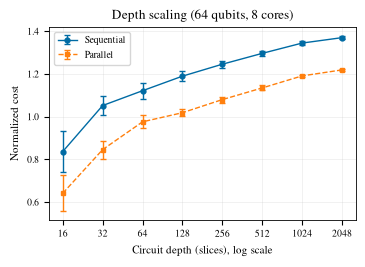

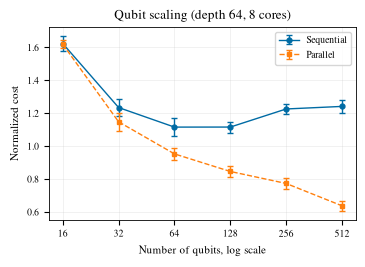

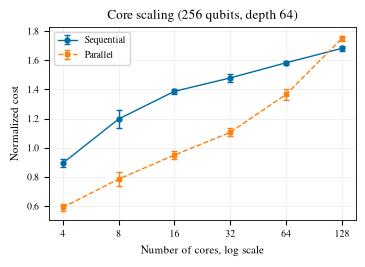

In [3]:
# Plot allocation performance scaling from depth, qubits and cores in three different plots. Each one should plot the average over the 10 samples of the normalized cost, that is, allocation_cost/(num_gates + 1)
# NOTE: 'costs' is already stored normalized as cost/(n_gates_norm + 1) by review._run_allocator
MODES = {'seq': 'Sequential', 'par': 'Parallel'}
MODE_STYLE = {
    'seq': dict(marker='o', linestyle='-',  hatch=''),
    'par': dict(marker='s', linestyle='--', hatch='////'),
    'hqa': dict(marker='^', linestyle=':',  hatch='....'),
}

def plot_scaling(data, xlabel, title, name, metric='costs', ylabel='Normalized cost', scale=1.0, yscale='linear', errorbars=False):
    ''' Mean +- std over the circuits of each configuration, for both allocator modes. Values are divided by `scale`.
    The std is drawn as error bars if `errorbars`, else as a shaded band. The figure is saved as FIG_DIR/<name>.<fmt>. '''
    fig, ax = plt.subplots()
    keys = list(data.keys())
    for i, (mode, label) in enumerate(MODES.items()):
        vals = [np.asarray(data[k][mode][metric], dtype=float) / scale for k in keys]
        mean = np.array([v.mean() for v in vals])
        std = np.array([v.std() for v in vals])
        style = dict(marker=MODE_STYLE[mode]['marker'], linestyle=MODE_STYLE[mode]['linestyle'], c=f'C{i}', label=label)
        if errorbars:
            ax.errorbar(keys, mean, yerr=std, **style)
        else:
            ax.plot(keys, mean, **style)
            ax.fill_between(keys, mean - std, mean + std, color=f'C{i}', alpha=0.2, linewidth=0)
    ax.set_xscale('log', base=2)
    ax.set_yscale(yscale)
    ax.set_xticks(keys, [str(k) for k in keys])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='best')
    save_fig(fig, name)
    plt.show()

# (data, x label, title, file name suffix)
BENCHMARKS = [
    (depth_data, 'Circuit depth (slices), log scale', 'Depth scaling (64 qubits, 8 cores)', 'depth'),
    (qubits_data, 'Number of qubits, log scale', 'Qubit scaling (depth 64, 8 cores)', 'qubits'),
    (cores_data, 'Number of cores, log scale', 'Core scaling (256 qubits, depth 64)', 'cores'),
]

for data, xlabel, title, name in BENCHMARKS:
    plot_scaling(data, xlabel, title, f'cost_{name}', errorbars=True)

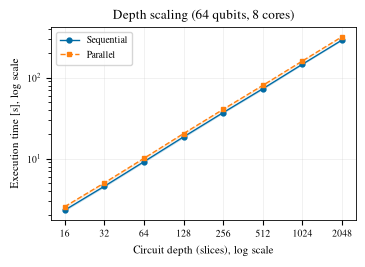

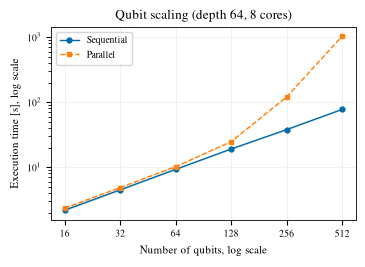

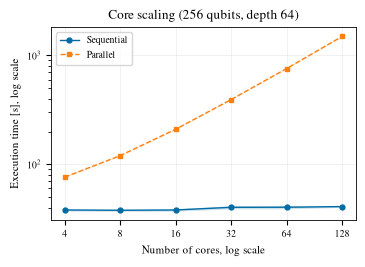

In [4]:
# Now add execution time for the three benchmarks
for data, xlabel, title, name in BENCHMARKS:
    plot_scaling(data, xlabel, title, f'time_{name}', metric='times', ylabel='Execution time [s], log scale', yscale='log')

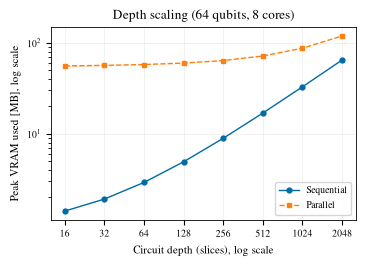

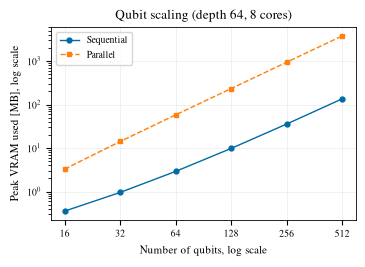

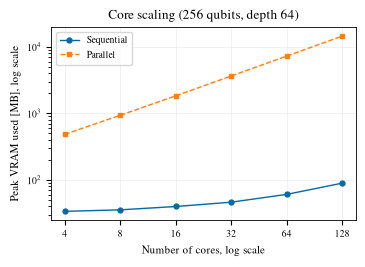

In [5]:
# Add memory consumption for the three benchmarks
# vram_delta = peak tensor memory during the allocation minus what was already allocated (i.e. excludes model weights).
# vram_reserved_peak is not plotted: PyTorch's caching allocator keeps memory from earlier tasks, so it is ~33GB regardless of the circuit.
MB = 2**20
for data, xlabel, title, name in BENCHMARKS:
    plot_scaling(data, xlabel, title, f'vram_{name}', metric='vram_delta', ylabel='Peak VRAM used [MB], log scale', scale=MB, yscale='log')

HQA computed locally for: ['all2all', 'linear', 'ring', 'star', 'grid']


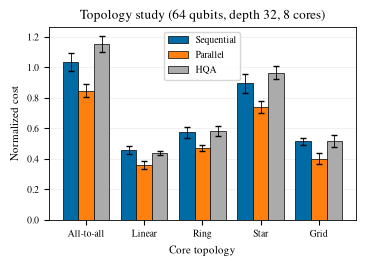

In [6]:
# You'll also find a new folder: data/partial/topology/. It contains results for different core topology configurations. Please plot only the normalized allocation cost as a bar plot, where the X axis contains the name of each topology. Make a dictionary of original names to plot names so that I can change them easily
# Original topology names (review.TOPOLOGIES keys) -> names shown in the plot. Dict order sets the bar order
TOPOLOGY_NAMES = {
    'all2all': 'All-to-all',
    'linear':  'Linear',
    'ring':    'Ring',
    'star':    'Star',
    'grid':    'Grid',
}

topology_data = partial.get('topology', {})
topologies = [t for t in TOPOLOGY_NAMES if t in topology_data]

# HQA runs in milliseconds on CPU, so the circuits without remote HQA results are computed here with the
# same tasks as review.py (same seeded circuits and hardware, allocations validated with check_sanity)
import torch
import review
from qalloczero.alg.hqa import HQA

n_circs = max(len(v['seq']['costs']) for v in topology_data.values())
incomplete = [t for t in topologies if len(topology_data[t].get('hqa', {}).get('costs', [])) != n_circs]
for t in incomplete:
    topology_data[t]['hqa'] = defaultdict(list)
for task in review._build_tasks(['topology'], n_circs):
    if task['key'] in incomplete:
        res = review._run_task(task, {'hqa': HQA()}, torch.device('cpu'), ['hqa'])['hqa']
        for m in METRICS:
            topology_data[task['key']]['hqa'][m].append(res[m])
print(f"HQA computed locally for: {incomplete}")

topology_modes = {**MODES, 'hqa': 'HQA'}
x = np.arange(len(topologies))
width = 0.8 / len(topology_modes)

fig, ax = plt.subplots()
for i, (mode, label) in enumerate(topology_modes.items()):
    vals = [np.asarray(topology_data[t][mode]['costs']) for t in topologies]
    ax.bar(x + (i - (len(topology_modes) - 1) / 2) * width, [v.mean() for v in vals], width,
           yerr=[v.std() for v in vals], color=f'C{i}',
           edgecolor='black', linewidth=0.5, error_kw=dict(elinewidth=0.6), label=label)
ax.set_xticks(x, [TOPOLOGY_NAMES[t] for t in topologies])
ax.set_xlabel('Core topology')
ax.set_ylabel('Normalized cost')
ax.set_title('Topology study (64 qubits, depth 32, 8 cores)')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc='best')
save_fig(fig, 'cost_topology')
plt.show()

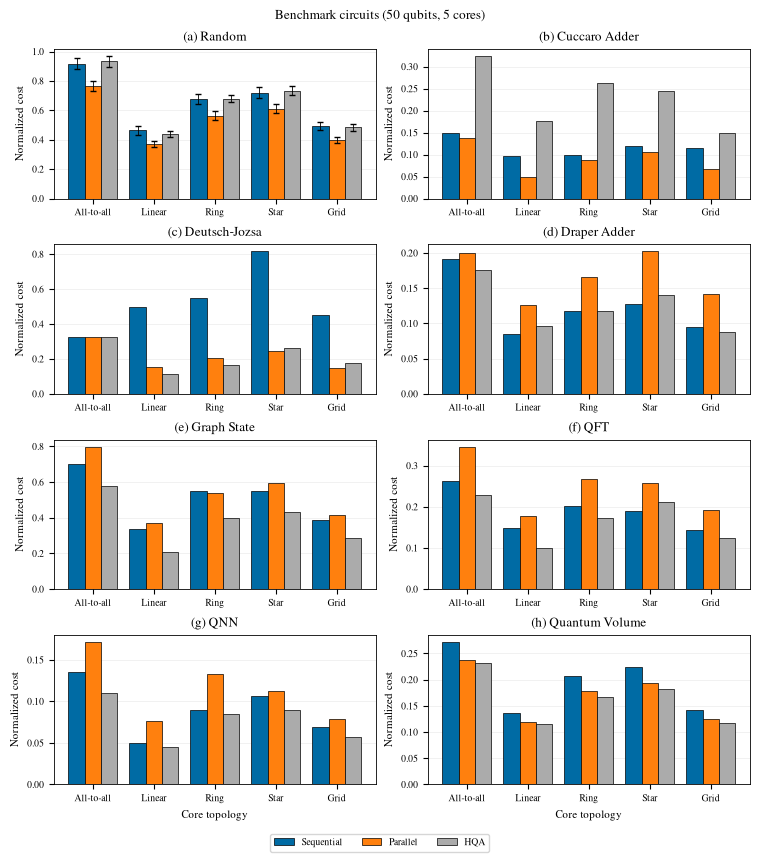

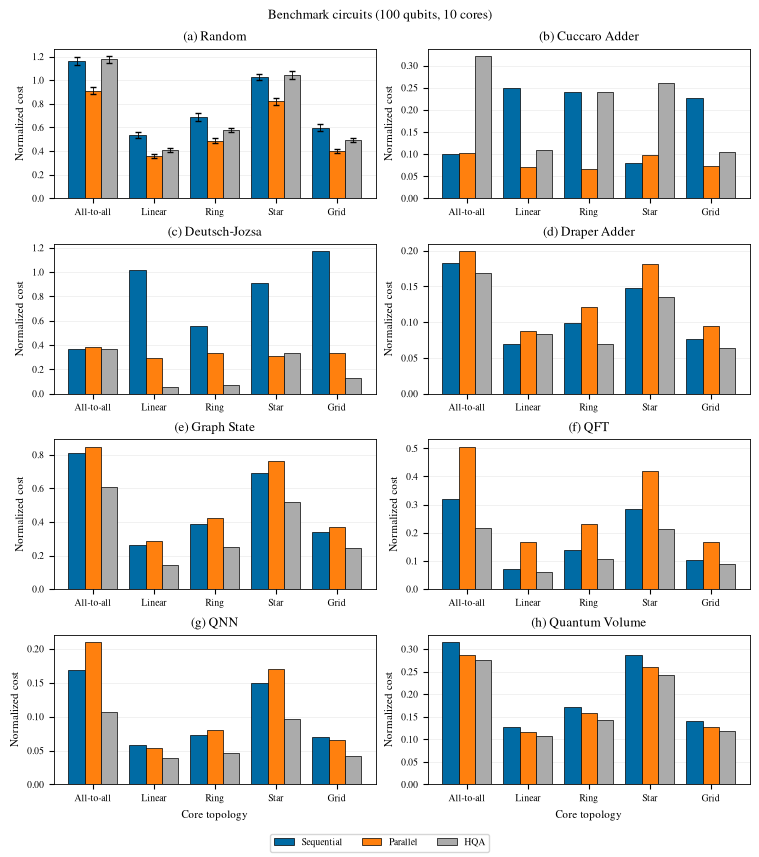

In [8]:
# Benchmark circuits (data/all_50.json and data/all_100.json) on every topology: one figure per size, with a subfigure per
# circuit type. The 64 random circuits are grouped into a single type, with error bars showing their std (the rest are
# single circuits). Full page width (190 mm), so each panel keeps the ~90 mm width and lettering of the single plots
# Original circuit names -> names shown in the plot. Dict order sets the subfigure order
CIRCUIT_NAMES = {
    'random':         'Random',
    'cuccaro_adder':  'Cuccaro Adder',
    'deutsch_jozsa':  'Deutsch-Jozsa',
    'drapper_adder':  'Draper Adder',
    'graph_state':    'Graph State',
    'qft':            'QFT',
    'qnn':            'QNN',
    'quantum_volume': 'Quantum Volume',
}
BENCH_MODES = {**MODES, 'hqa': 'HQA'}

def circuit_type(name):
    return 'random' if name.startswith('random') else name

BENCH_COLS = 2
BENCH_ROWS = -(-len(CIRCUIT_NAMES) // BENCH_COLS)

for study, bench in review.BENCHMARKS.items():
    bench_data = partial.get(study, {})
    if not bench_data:
        print(f"No results for {study}")
        continue
    bench_topologies = [t for t in TOPOLOGY_NAMES if t in bench_data]
    modes = {m: l for m, l in BENCH_MODES.items() if all(m in bench_data[t] for t in bench_topologies)}
    n_qubits = int(study.removeprefix('bench'))
    n_cores = n_qubits // bench['qubits_per_core']
    x = np.arange(len(bench_topologies))
    width = 0.8 / len(modes)

    fig, axs = plt.subplots(BENCH_ROWS, BENCH_COLS, figsize=(190 * MM, BENCH_ROWS * 50 * MM + 15 * MM), squeeze=False)
    for p_i, (ax, (ctype, cname)) in enumerate(zip(axs.flat, CIRCUIT_NAMES.items())):
        for i, (mode, label) in enumerate(modes.items()):
            vals = []
            for t in bench_topologies:
                d = bench_data[t][mode]
                vals.append(np.array([c for c, name in zip(d['costs'], d['idx']) if circuit_type(name) == ctype]))
            ax.bar(x + (i - (len(modes) - 1) / 2) * width, [v.mean() for v in vals], width,
                   yerr=[v.std() for v in vals] if ctype == 'random' else None, color=f'C{i}',
                   edgecolor='black', linewidth=0.5, error_kw=dict(elinewidth=0.6), label=label)
        ax.set_xticks(x, [TOPOLOGY_NAMES[t] for t in bench_topologies])
        ax.set_ylabel('Normalized cost')
        ax.set_title(f'({chr(ord("a") + p_i)}) {cname}')
        ax.grid(axis='y', alpha=0.3)
        ax.set_axisbelow(True)
    for ax in axs.flat[len(CIRCUIT_NAMES):]:
        ax.set_visible(False)
    for ax in axs[-1]:
        ax.set_xlabel('Core topology')
    fig.suptitle(f'Benchmark circuits ({n_qubits} qubits, {n_cores} cores)')
    handles, labels = axs.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='outside lower center', ncols=len(modes))
    # save_fig(fig, f'cost_{study}')
    plt.show()